In [1]:
from plastic_neuron import PlasticNeuron
from abstract_neuron import AbstractNeuron
from neuron_utils import NeuronUtils
from neuron_plots import NeuronPlots
import matplotlib.pyplot as plt
from neuron import h
import numpy as np

# Running LTP protocol with and without electric field

The neuron has 10 synapses.

The synapses receive potentiating inputs of 100 Hz, starting at 500 ms and ending at 1500 ms.

In [2]:
run_duration = 2000
ltp_duration = 1000
frequency = 100

In [3]:
def generate_ltp_stimulus():
    stimulus = h.NetStim()
    stimulus.interval = int(1000 / frequency)
    stimulus.number = int(ltp_duration / stimulus.interval) + 1
    stimulus.noise = 0
    stimulus.start = 0

    return stimulus

neuron = PlasticNeuron(
    n_synapses = 10,
    initial_conductance = 0.0001,
    generate_stimulus = generate_ltp_stimulus,
    generate_delay = lambda: int((run_duration - ltp_duration) / 2),
    seed = 69
)

Creating cell
	1 
	1 
	0 
23 
After any change to cell geometry or nseg, be sure to invoke setpointers()
Generating synapse information
Inserting 10 synapses


In [4]:
neuron.synapse_info

,Dendrite,Location,Distance,Delay,Conductance,InitialWeight
0,27,0.567046,290.866720,500,0.0001,0
1,25,0.064349,187.066273,500,0.0001,0
2,18,0.147210,114.094727,500,0.0001,0
3,13,0.693678,177.594646,500,0.0001,0
4,13,0.103263,134.103692,500,0.0001,0
5,23,0.889141,292.576010,500,0.0001,0
6,5,0.702076,208.425386,500,0.0001,0
7,2,0.255111,123.090113,500,0.0001,0
8,25,0.910514,204.630600,500,0.0001,0
9,17,0.154149,116.174802,500,0.0001,0


## Synaptic plasticity without electric field

In [5]:
NeuronUtils.set_stimulus(duration = 0)
neuron.run(duration = run_duration)

Neuron initialized
Elapsed time: 46.85 seconds


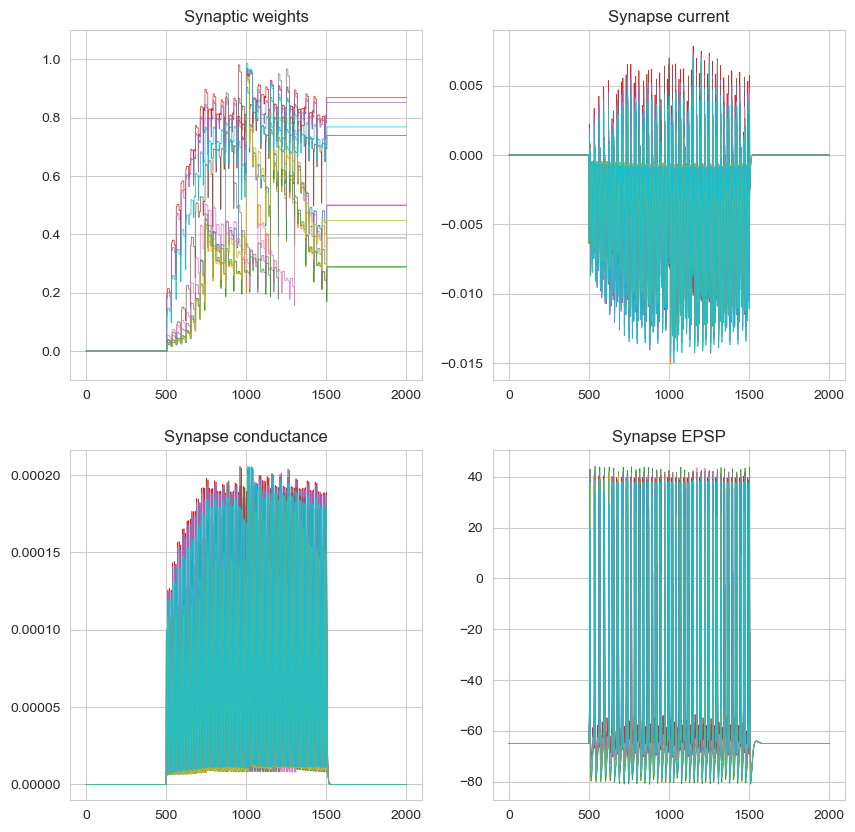

In [6]:
NeuronPlots.plot_all_synapses(neuron)

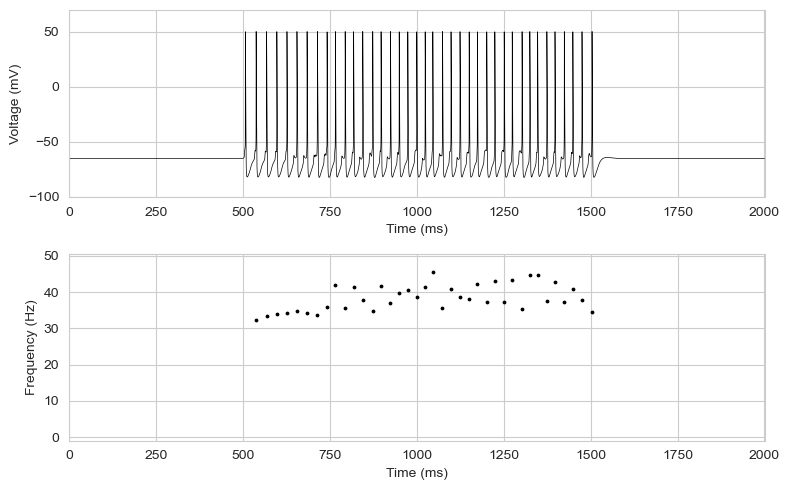

In [7]:
NeuronPlots.plot_spike_frequency(neuron)

## Synaptic plasticity in TI electric field (5 Hz)

In [8]:
NeuronUtils.set_stimulus(
    duration = run_duration,
    frequency1 = 1000,
    frequency2 = 1005,
    phase = 10,
    amplitude = 120,
    delay = 0
)

neuron.run(duration = run_duration)

Neuron initialized
Elapsed time: 46.72 seconds


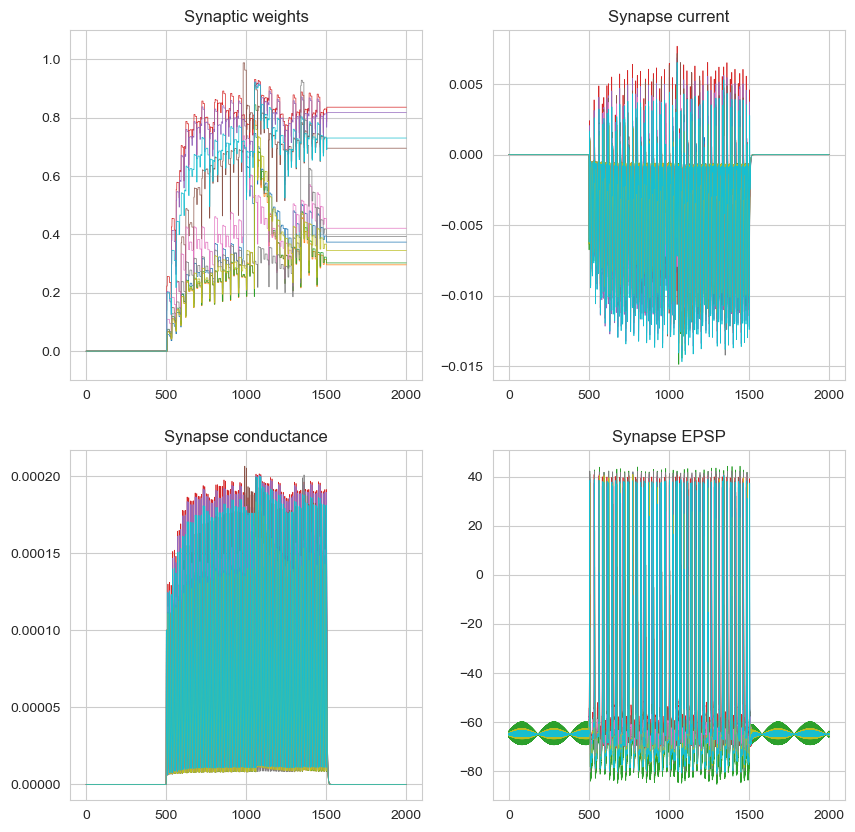

In [9]:
NeuronPlots.plot_all_synapses(neuron)

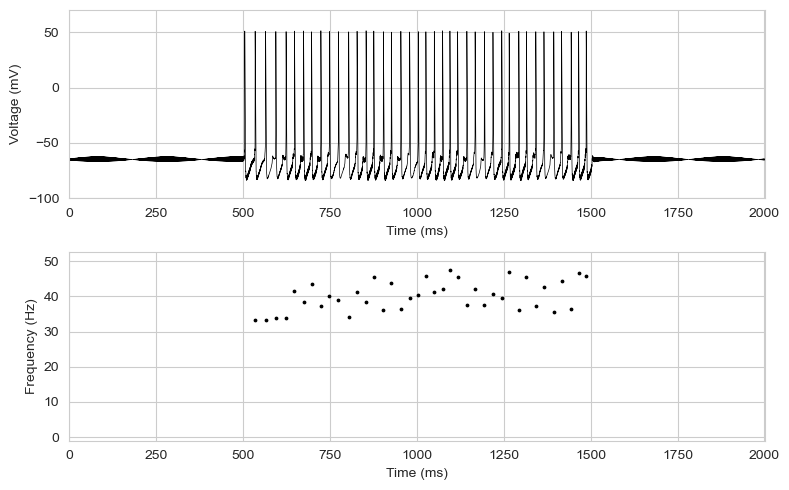

In [10]:
NeuronPlots.plot_spike_frequency(neuron)